In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
    ExtraTreesClassifier
)
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

import warnings
warnings.filterwarnings("ignore")

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
df = pd.read_csv("realistic_employee_attrition.csv")

print("Dataset loaded successfully!")
print("Shape:", df.shape)

df.head()

Dataset loaded successfully!
Shape: (100000, 10)


,Age,JobLevel,MonthlyIncome,YearsAtCompany,StockOptionLevel,DistanceFromHome,OverTime,WorkLifeBalance,JobSatisfaction,Attrition
0,44,4,13544.0,3,3,1,No,3,4,No
1,44,4,13296.0,3,3,21,No,4,4,No
2,32,3,8894.0,3,2,4,Yes,2,2,Yes
3,29,1,3442.0,0,0,2,No,4,4,No
4,52,5,20906.0,10,3,21,No,3,4,No


In [3]:
print("Dataset Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

Dataset Shape: (100000, 10)

Columns:
['Age', 'JobLevel', 'MonthlyIncome', 'YearsAtCompany', 'StockOptionLevel', 'DistanceFromHome', 'OverTime', 'WorkLifeBalance', 'JobSatisfaction', 'Attrition']

Data Types:
Age                   int64
JobLevel              int64
MonthlyIncome       float64
YearsAtCompany        int64
StockOptionLevel      int64
DistanceFromHome      int64
OverTime             object
WorkLifeBalance       int64
JobSatisfaction       int64
Attrition            object
dtype: object

Missing Values:
Age                 0
JobLevel            0
MonthlyIncome       0
YearsAtCompany      0
StockOptionLevel    0
DistanceFromHome    0
OverTime            0
WorkLifeBalance     0
JobSatisfaction     0
Attrition           0
dtype: int64


In [4]:
print("Duplicates before:", df.duplicated().sum())

df = df.drop_duplicates().reset_index(drop=True)

print("Duplicates after:", df.duplicated().sum())
print("New shape:", df.shape)

Duplicates before: 22
Duplicates after: 0
New shape: (99978, 10)


In [5]:
df.columns = df.columns.str.strip()

print(df.columns.tolist())

['Age', 'JobLevel', 'MonthlyIncome', 'YearsAtCompany', 'StockOptionLevel', 'DistanceFromHome', 'OverTime', 'WorkLifeBalance', 'JobSatisfaction', 'Attrition']


Attrition
No     49995
Yes    49983
Name: count, dtype: int64


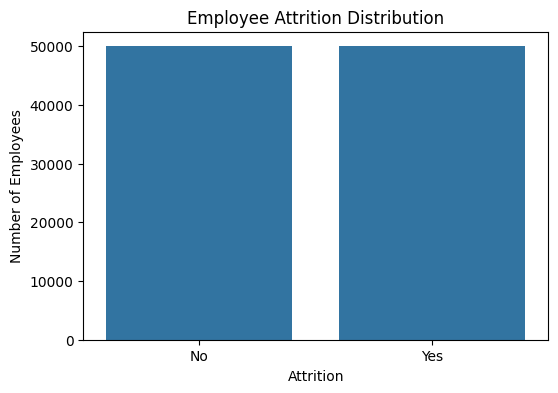

In [6]:
print(df["Attrition"].value_counts())

plt.figure(figsize=(6, 4))

sns.countplot(data=df, x="Attrition")

plt.title("Employee Attrition Distribution")
plt.xlabel("Attrition")
plt.ylabel("Number of Employees")

plt.show()

In [7]:
df["OverTime"] = df["OverTime"].map({
    "Yes": 1,
    "No": 0
})

df["Attrition"] = df["Attrition"].map({
    "Yes": 1,
    "No": 0
})

print(df.head())

   Age  JobLevel  MonthlyIncome  YearsAtCompany  StockOptionLevel  \
0   44         4        13544.0               3                 3   
1   44         4        13296.0               3                 3   
2   32         3         8894.0               3                 2   
3   29         1         3442.0               0                 0   
4   52         5        20906.0              10                 3   

   DistanceFromHome  OverTime  WorkLifeBalance  JobSatisfaction  Attrition  
0                 1         0                3                4          0  
1                21         0                4                4          0  
2                 4         1                2                2          1  
3                 2         0                4                4          0  
4                21         0                3                4          0  


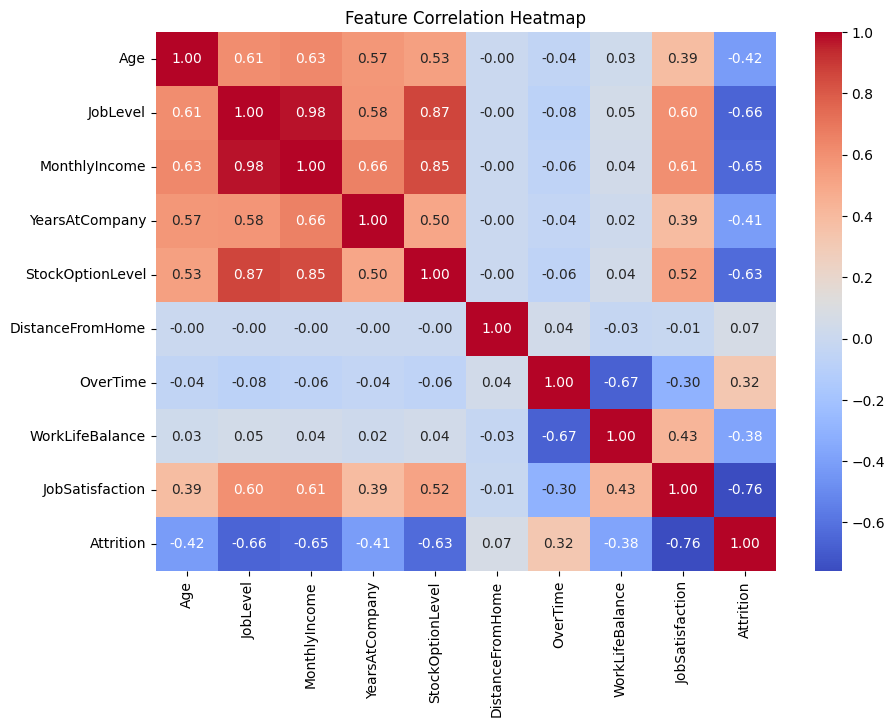

In [8]:
plt.figure(figsize=(10, 7))

correlation = df.corr(numeric_only=True)

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Feature Correlation Heatmap")
plt.show()

In [9]:
df["AnnualIncome"] = df["MonthlyIncome"] * 12

df["CompanyAgeRatio"] = (
    df["YearsAtCompany"] / (df["Age"] + 1)
)

df["IncomePerJobLevel"] = (
    df["MonthlyIncome"] / (df["JobLevel"] + 1)
)

df["SatisfactionScore"] = (
    df["WorkLifeBalance"] +
    df["JobSatisfaction"]
) / 2

df.head()

,Age,JobLevel,MonthlyIncome,YearsAtCompany,StockOptionLevel,DistanceFromHome,OverTime,WorkLifeBalance,JobSatisfaction,Attrition,AnnualIncome,CompanyAgeRatio,IncomePerJobLevel,SatisfactionScore
0,44,4,13544.0,3,3,1,0,3,4,0,162528.0,0.066667,2708.800000,3.5
1,44,4,13296.0,3,3,21,0,4,4,0,159552.0,0.066667,2659.200000,4.0
2,32,3,8894.0,3,2,4,1,2,2,1,106728.0,0.090909,2223.500000,2.0
3,29,1,3442.0,0,0,2,0,4,4,0,41304.0,0.000000,1721.000000,4.0
4,52,5,20906.0,10,3,21,0,3,4,0,250872.0,0.188679,3484.333333,3.5


In [10]:
X = df.drop("Attrition", axis=1)

y = df["Attrition"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (99978, 13)
y shape: (99978,)


In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (79982, 13)
Testing data: (19996, 13)


In [12]:
models = {

    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(max_iter=2000))
    ]),

    "KNN": Pipeline([
        ("scaler", StandardScaler()),
        ("model", KNeighborsClassifier(n_neighbors=5))
    ]),

    "Decision Tree": DecisionTreeClassifier(
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ),

    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    ),

    "Extra Trees": ExtraTreesClassifier(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    )
}

In [13]:
results = []

for name, model in models.items():

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test)[:, 1]
    else:
        y_prob = None

    roc_auc = roc_auc_score(y_test, y_prob)

    results.append({
        "Model": name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1,
        "ROC-AUC": roc_auc
    })

results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="Accuracy",
    ascending=False
)

results_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.931036,0.927056,0.935681,0.931349,0.984937
4,Gradient Boosting,0.930586,0.926568,0.935281,0.930904,0.984571
3,Random Forest,0.923985,0.920444,0.928178,0.924295,0.980674
5,Extra Trees,0.921434,0.918288,0.925178,0.921720,0.979970
1,KNN,0.920034,0.917811,0.922677,0.920237,0.968132
2,Decision Tree,0.896879,0.894109,0.900370,0.897229,0.896880


In [ ]:
rf = RandomForestClassifier(
    random_state=42,
    n_jobs=-1
)

param_grid = {
    "n_estimators": [200, 300],
    "max_depth": [None, 10, 15, 20],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2"]
}

grid_rf = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1,
    verbose=1
)

grid_rf.fit(X_train, y_train)

print("Best Parameters:")
print(grid_rf.best_params_)

print("\nBest CV Accuracy:")
print(grid_rf.best_score_)

Fitting 5 folds for each of 144 candidates, totalling 720 fits


In [ ]:
best_rf = grid_rf.best_estimator_

y_pred_rf = best_rf.predict(X_test)

accuracy = accuracy_score(y_test, y_pred_rf)

print("Random Forest Test Accuracy:",
      round(accuracy * 100, 2), "%")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

In [ ]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": best_rf.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=importance,
    x="Importance",
    y="Feature"
)

plt.title("Feature Importance - Random Forest")

plt.show()

importance